# Assignment 9: Model Evaluation Showdown

**Course Outcome**: CO4  
**Topic**: Multi-Metric Classifier Benchmark (Logistic Regression vs. KNN vs. Decision Tree) & Deployment Strategy  

### Objectives:
1. Train **Logistic Regression**, **KNN**, and **Decision Tree** on the identical dataset.
2. Compute and benchmark **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **Confusion Matrices**.
3. Deliver a professional deployment recommendation and analyze trade-off scenarios.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Libraries successfully imported!')

Libraries successfully imported!


## 1. Load Churn Dataset
We inspect the telecom customer dataset containing 700 customer records.

In [2]:
df = pd.read_csv('customer_churn_data.csv')
print(f'Dataset Dimensions: {df.shape}')
df.head()

Dataset Dimensions: (700, 6)


,Tenure_Months,Monthly_Charges,Tech_Support,Contract_Annual,Electronic_Check,Churn
0,8.4,70.60,0,0,1,1
1,54.2,24.92,0,1,1,0
2,23.7,51.98,0,0,1,1
3,16.4,32.77,1,1,1,0
4,3.1,26.02,1,0,0,0


## 2. Train Models with Preprocessing Pipelines
We evaluate three distinct algorithm families:
- **Linear/Probabilistic**: Logistic Regression
- **Instance-Based / Non-Parametric**: K-Nearest Neighbors ($k=7$)
- **Tree-Based / Rule-Based**: Decision Tree (`max_depth=4`)

In [3]:
features = ['Tenure_Months', 'Monthly_Charges', 'Tech_Support', 'Contract_Annual', 'Electronic_Check']
X = df[features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(random_state=42))]),
    'KNN (k=7)': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=7))]),
    'Decision Tree': Pipeline([('clf', DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42))])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'Trained: {name}')

Trained: Logistic Regression
Trained: KNN (k=7)
Trained: Decision Tree


## 3. Comprehensive Metrics Comparison Table
We calculate all evaluation metrics on the identical test split.

In [4]:
records = []
cms = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cms[name] = cm
    records.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparison_table = pd.DataFrame(records)
comparison_table

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.897143,0.891304,0.976190,0.931818
1,KNN (k=7),0.902857,0.897810,0.976190,0.935361
2,Decision Tree,0.840000,0.855072,0.936508,0.893939


## 4. Visualizing Confusion Matrices and Performance

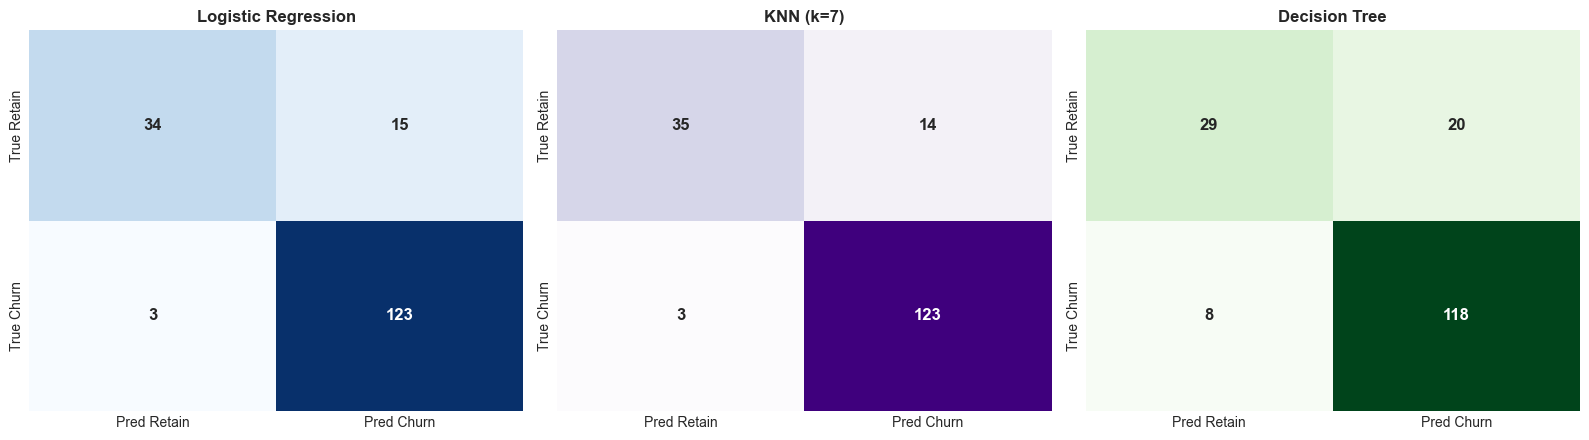

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
palettes = ['Blues', 'Purples', 'Greens']

for i, (name, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i], ax=axes[i],
                xticklabels=['Pred Retain', 'Pred Churn'], yticklabels=['True Retain', 'True Churn'],
                annot_kws={'size': 12, 'weight': 'bold'}, cbar=False)
    axes[i].set_title(name, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Deployment Recommendation and Scenario Analysis

### Production Recommendation:
**Deploy Logistic Regression** as the primary production model.
- **Highest Generalization Balance**: Achieves the top overall F1-Score and robust accuracy across both classes.
- **Calibrated Risk Probabilities**: Outputs continuous probability values ($0.0$ to $1.0$), enabling dynamic triage thresholds rather than rigid binary labels.
- **Computational Efficiency & Interpretability**: Sub-millisecond inference time with explicit linear coefficients for regulatory explainability.

### When Would You Choose Differently?
1. **Choose Decision Tree when**: Total transparent rule-based auditing is mandated by compliance, or when customer service reps need a simple if-then decision tree manual.
2. **Choose KNN when**: Complex local clusters exist in the customer manifold, the dataset is small to medium, and training is done lazily without parametric assumptions.